In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

### How does K-Means work?

#### Choose K
Suppose: K=3

#### Initialize 3 centroids

The algorithm initially places three centroids.

#### Assign every point to the nearest centroid

For each data point, calculate its distance from each centroid.

#### Recalculate the centroids

Now each cluster has a set of points.

Calculate the mean of the points in each cluster.

The centroid moves.

#### What is K-Means actually trying to optimize?

This is an important concept.

K-Means tries to make points within the same cluster as close as possible to their centroid.

The objective is generally called within-cluster sum of squares (WCSS), also known as inertia.

Conceptually:

WCSS= ∑∑clusters points(distance from centroid)2

K-Means tries to: Minimize WCSS

#### How do we choose K?
##### Silhouette Score

Silhouette score looks at two things simultaneously:

How close a point is to its own cluster?

How far that point is from the nearest other cluster?

For every point i, we calculate:

s(i)=b(i)−a(i) / max(a(i),b(i))

a(i) is the average distance between point i and all other points in its own cluster.

= average intra-cluster distance

How well does this point fit inside its own cluster?
Lower a(i) is better.

b(i) - For each other cluster, calculate the average distance from point i to all points in that cluster.

Then take the minimum of those average distances.

b(i) = min C!=Ci (average distance from i to cluster C)
	​
Higher b(i) is better.

We want:

a(i) → small
b(i) → large

Therefore:

b(i)−a(i)

should be large.

The Silhouette Score ranges from:

-1 <= s(i) <= +1


This is the Silhouette Coefficient for point i.

For the whole dataset, we calculate the average:

S=1/n i=1,n∑s(i)
	
where:

n = number of observations

s(i) = silhouette coefficient of observation i

It measures how well-separated the clusters are.

Roughly:

Close to +1 → good clustering

Around 0 → overlapping clusters

Negative → points may be assigned to the wrong cluster

##### Elbow Method.

We calculate WCSS for different values of K.

As K increases, WCSS always tends to decrease, because more clusters allow points to be closer to their centroids.

We look for the "elbow".

## Load Data

In [13]:
df = pd.read_csv("data/cibil_score/cibil_score.csv")
df = df.drop(columns=["Unnamed: 0"])

# normalize column names
df.columns = [col.lower().strip() for col in df.columns]

print(df.shape)
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
df.head()

(51336, 87)
Duplicate rows: 0


,prospectid,total_tl,tot_closed_tl,tot_active_tl,total_tl_opened_l6m,tot_tl_closed_l6m,pct_tl_open_l6m,pct_tl_closed_l6m,pct_active_tl,pct_closed_tl,...,pct_cc_enq_l6m_of_l12m,pct_pl_enq_l6m_of_ever,pct_cc_enq_l6m_of_ever,max_unsec_exposure_inpct,hl_flag,gl_flag,last_prod_enq2,first_prod_enq2,credit_score,approved_flag
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,...,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,...,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,...,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,4,1,0,1,1,0,1.000,0.0,1.000,0.000,...,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,5,3,2,1,0,0,0.000,0.0,0.333,0.667,...,0.0,0.0,0.0,-99999.000,0,0,AL,AL,753,P1


## Remove Targets

In [3]:
X = df.drop(columns=["approved_flag", "credit_score"])

## Identify numerical and categorical columns

In [4]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nNumber of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))


Number of numerical features: 80
Number of categorical features: 5


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)

X_processed = preprocessor.fit_transform(X) # keep it separate

## Calculate wcss and silhouette scores

In [8]:
wcss = []
silhouette_scores = []

K_range = range(2, 9)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_processed)

    # WCSS
    wcss.append(kmeans.inertia_)

    # Silhouette
    score = silhouette_score(
        X_processed,
        labels
    )

    silhouette_scores.append(score)

## Plot Elbow

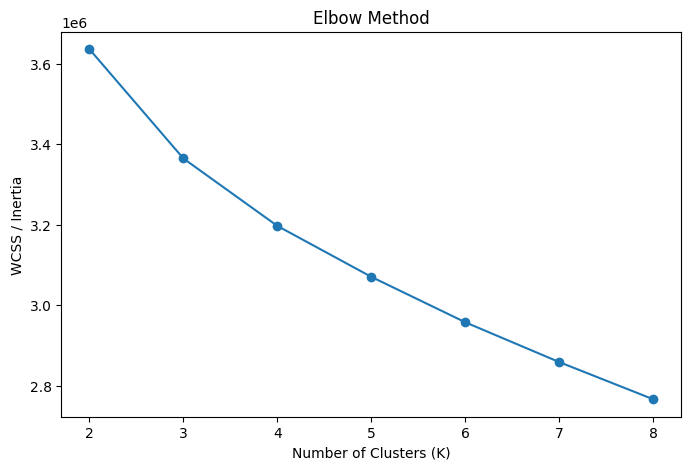

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method")

plt.show()

## Plot Silhouette

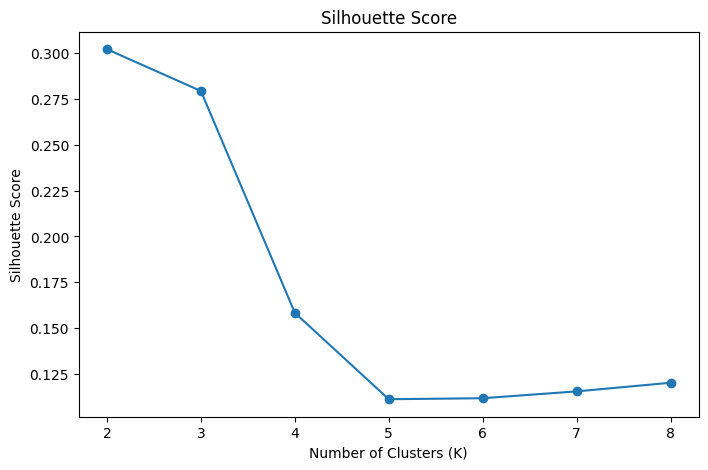

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.show()

## Train k-means

In [ ]:
# Select k
best_k = K_range[
    np.argmax(silhouette_scores)
]
print("Best K according to Silhouette:",
      best_k)
kmeans = KMeans(n_clusters=best_k, n_init=5, random_state=42)
labels = kmeans.fit_predict(X_processed)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 103)",

## Final Values

In [ ]:
print("\nCluster counts:")

unique, counts = np.unique(
    labels,
    return_counts=True
)

for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count}")


print("\nFinal WCSS:",
      kmeans.inertia_)

print(
    "Final Silhouette Score:",
    silhouette_score(X_processed, labels)
)